In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.width', 500)

In [3]:
def load_dataset():
    df = pd.read_csv("data/wdbc_data.csv", index_col=0)
    return df

In [4]:
def check_df(dataframe):
    """
    Checks the overall structure and key metrics of a DataFrame.

    Args:
        dataframe (pd.DataFrame): DataFrame to inspect.

    Returns:
        None: Prints shape, data types, head, tail, missing values, and quantiles.
    """
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(5))
    print("##################### Tail #####################")
    print(dataframe.tail(5))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print('##################### Unique Values #####################')
    print(dataframe.nunique())
    print("##################### Duplicates #####################")
    print(dataframe.duplicated().sum())
    print("##################### Quantiles #####################")
    # Uncomment below to include quantile information
    #print(dataframe[[col for col in dataframe.columns if dataframe[col].dtypes != "O"]].quantile([0, 0.05, 0.50, 0.75, 0.95, 0.99, 1]).T)
    print(dataframe.describe().T)

In [5]:
df = load_dataset()

In [6]:
check_df(df)

##################### Shape #####################
(569, 32)
##################### Types #####################
ID                      int64
Diagnosis               int64
radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3     

**BAYESIAN NETWORK**

In [7]:
import bnlearn as bn
from pgmpy.models.LinearGaussianBayesianNetwork import LinearGaussianBayesianNetwork

In [8]:
dependencies_structure = bn.structure_learning.fit(df=df, methodtype='hc', scoretype='bic')

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


In [9]:
bn.plot(dependencies_structure)

[bnlearn]> Nothing to plot because no edges are present between nodes. 


In [11]:
def correlation_matrix(df, cols):
    """
    Visualizes the correlation matrix for specified columns.

    Args:
        df (pd.DataFrame): DataFrame to analyze.
        cols (list): List of columns to include in the correlation matrix.

    Returns:
        None: Displays a heatmap.
    """
    fig = plt.gcf()
    fig.set_size_inches(20, 16)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    fig = sns.heatmap(df[cols].corr(), annot=True, linewidths=0.5,
                      annot_kws={'size': 8}, linecolor='w', cmap='vlag')
    plt.show(block=True)

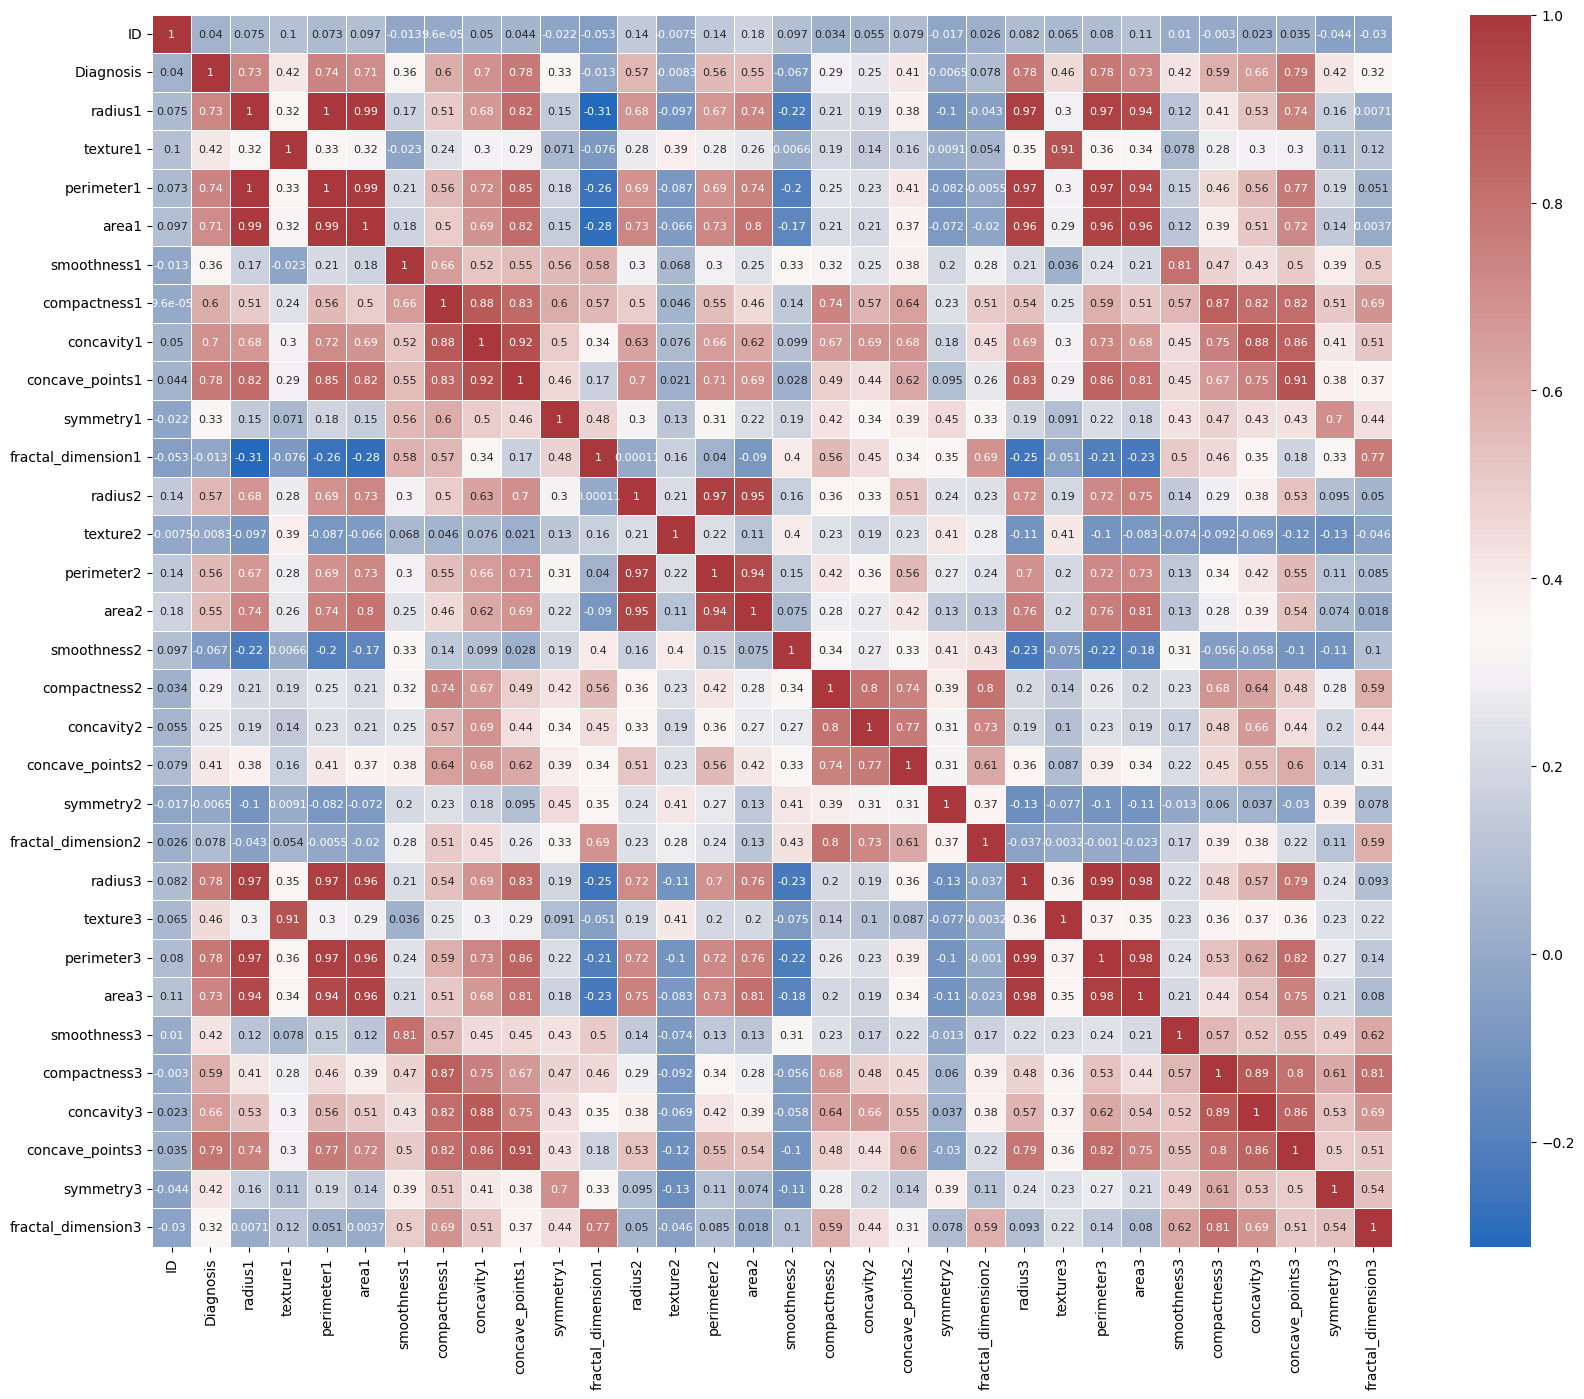

In [12]:
correlation_matrix(df=df, cols=df.columns)

**OBSERVATIONS**
- No dependencies were found but correlation matrix shows a contrast result.
- Probably, function parameters or scoring tecnique did not suit well for our continious features and small dataset

In [13]:
dependencies_structure = bn.structure_learning.fit(df=df, methodtype='hc', scoretype='aic') #trying another scoring technique

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [aic]
[bnlearn] >Compute structure scores for model comparison (higher is better).


In [14]:
bn.plot(dependencies_structure)

[bnlearn]> Nothing to plot because no edges are present between nodes. 


Scoring based methods cant find a dependency so we switch to statistical tests based methods

In [15]:
dependencies_structure = bn.structure_learning.fit(df=df, methodtype='cs')

[bnlearn] >Computing best DAG using [cs]
[bnlearn] >Build skeleton with [chi_square] and alpha=0.05


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Warning: Structure scoring could not be computed. Method [cs] not supported.


**Fallout Strategy: Discretization**

In [ ]:
#df.drop(columns=['ID'], axis=1, inplace=True)

In [16]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.20, random_state=26)

In [31]:
check_df(df_train)

##################### Shape #####################
(455, 32)
##################### Types #####################
ID                      int64
Diagnosis               int64
radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3     

In [17]:
from sklearn.preprocessing import KBinsDiscretizer
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

**Quantile based discretization is applied to combat outlier and noise affect on data.**

In [18]:
cols_without_target_and_id = [col for col in df.columns if col not in ['ID', 'Diagnosis']]

In [32]:
df_train_discrete = pd.DataFrame(discretizer.fit_transform(df_train[cols_without_target_and_id]), 
                                 columns=cols_without_target_and_id)

df_train_discrete['Diagnosis'] = df_train['Diagnosis'].values

df_test_discrete = pd.DataFrame(discretizer.transform(df_test[cols_without_target_and_id]), 
                                columns=cols_without_target_and_id)

df_test_discrete['Diagnosis'] = df_test['Diagnosis'].values

In [33]:
check_df(df_train_discrete)

##################### Shape #####################
(455, 31)
##################### Types #####################
radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3  

**SCALING**

In [21]:
from sklearn.preprocessing import MinMaxScaler

In [22]:
scaler = MinMaxScaler()

In [34]:
df_train_discrete = pd.DataFrame(scaler.fit_transform(df_train_discrete), columns=df_train_discrete.columns)
df_test_discrete = pd.DataFrame(scaler.transform(df_test_discrete), columns=df_test_discrete.columns)

[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >Set node properties.
[bnlearn] >Set edge properties.
[bnlearn] >Plot based on Bayesian model


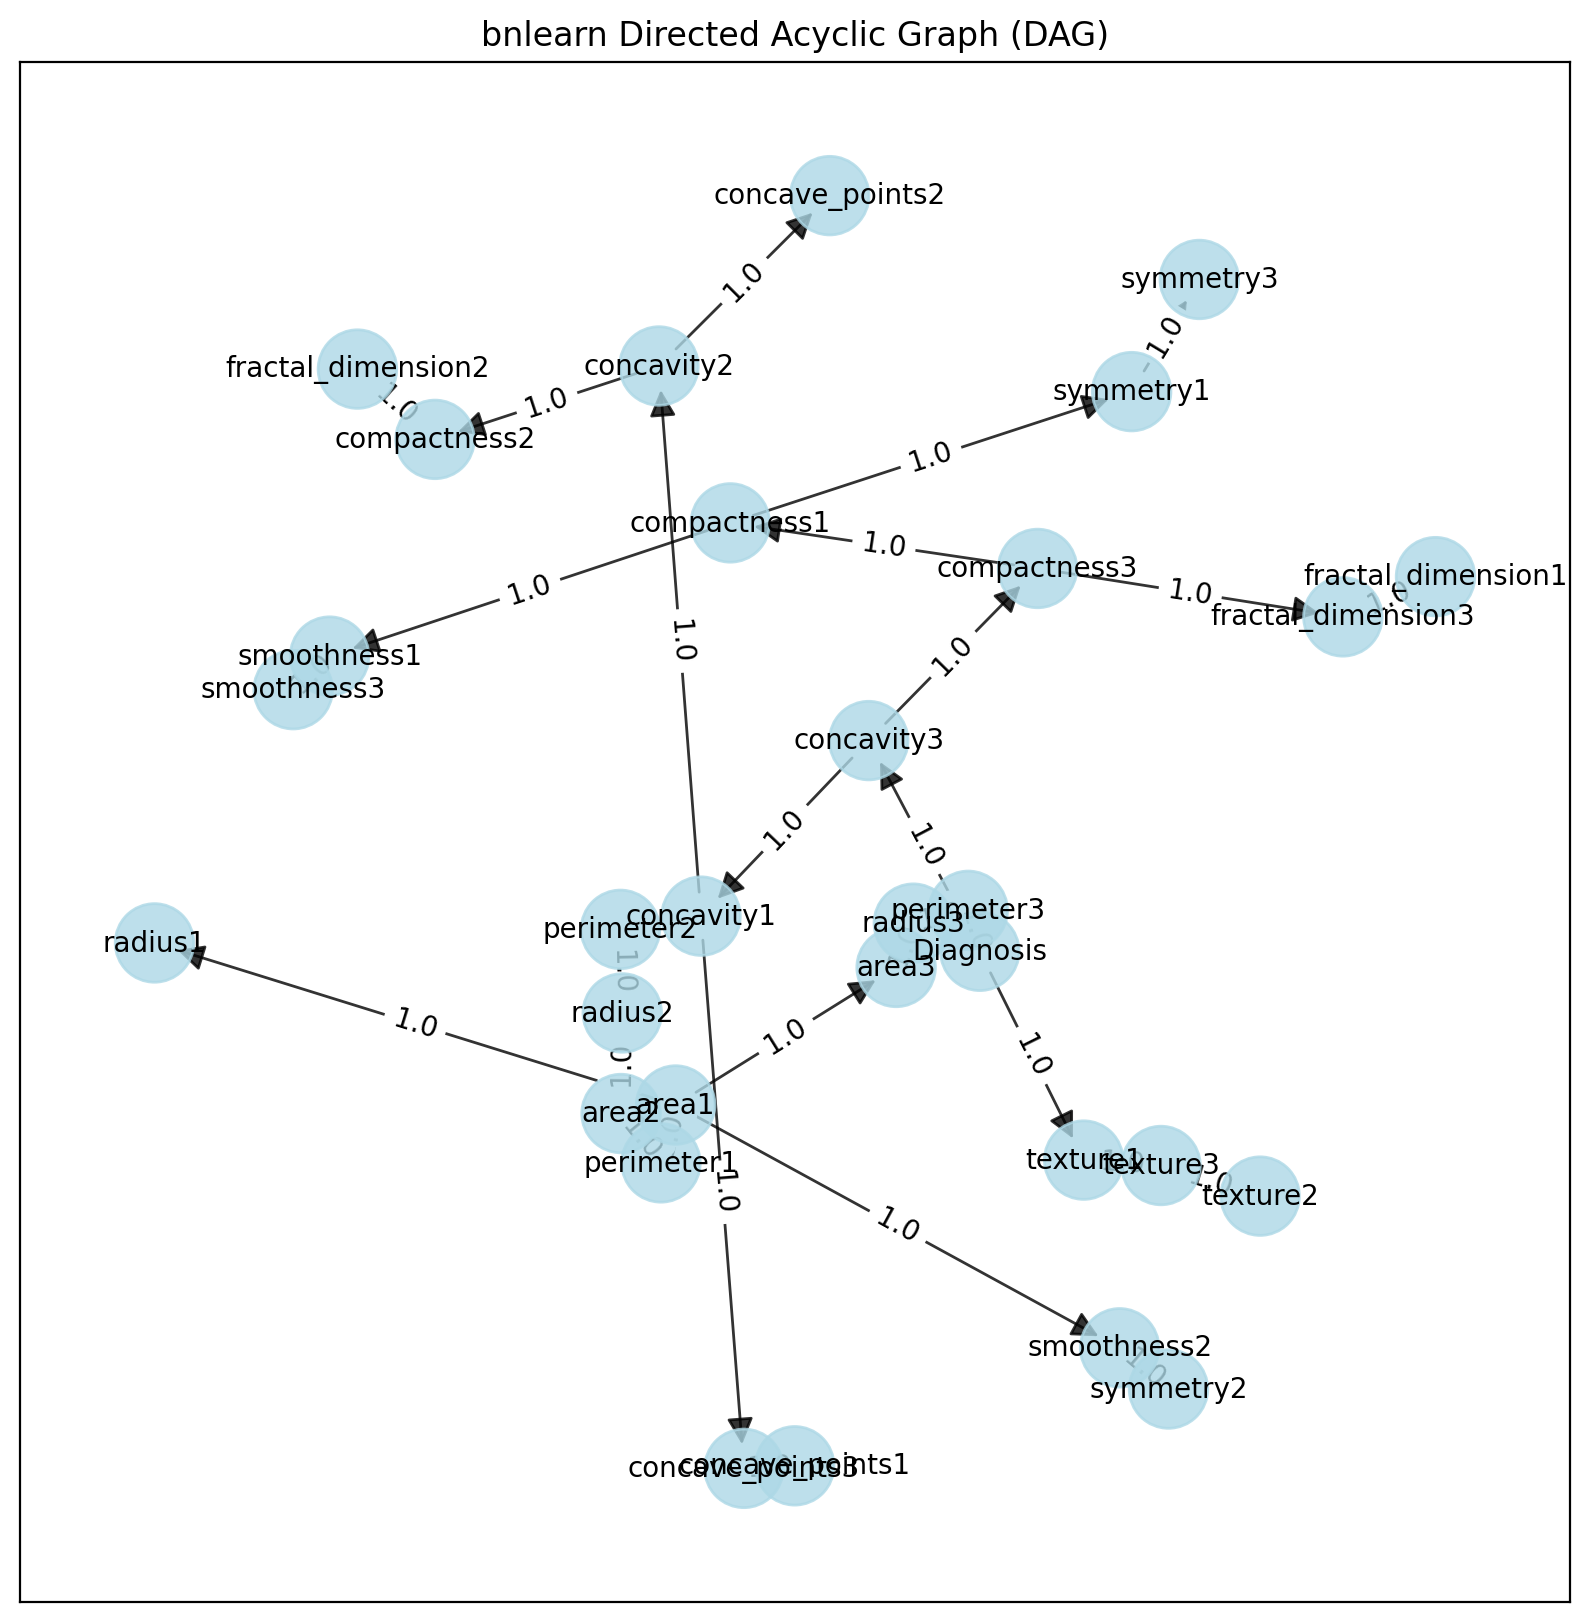

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'texture1': array([ 0.37132947, -0.45933747]),
  'texture3': array([ 0.48539804, -0.46749706]),
  'perimeter1': array([-0.25257561, -0.46353188]),
  'area1': array([-0.23092501, -0.37608672]),
  'radius1': array([-1.        , -0.13116425]),
  'smoothness2': array([ 0.42437154, -0.74299824]),
  'area3': array([ 0.09451185, -0.16818043]),
  'smoothness1': array([-0.74162795,  0.30224432]),
  'smoothness3': array([-0.79531707,  0.25155666]),
  'compactness1': array([-0.1502205 ,  0.50358185]),
  'symmetry1': array([0.44208934, 0.7019459 ]),
  'concavity1': array([-0.19345011, -0.09065332]),
  'concavity2': array([-0.25553178,  0.74068067]),
  'concave_points3': array([-0.13009619, -0.92516168]),
  'symmetry3': array([0.54197815, 0.87142831]),
  'radius2': array([-0.30965995, -0.23695491]),
  'area2': array([-0.31146863, -0.38894876]),
  'perimeter2': array([-0.31236178, -0.11067192]),
  'symm

In [35]:
dependencies_structure = bn.structure_learning.fit(df_train_discrete, methodtype='hc', scoretype='bic')


bn.plot(dependencies_structure)

In [36]:
bayesian_network_model = bn.parameter_learning.fit(dependencies_structure, df_train_discrete)

[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of texture1:
+----------------+---------------------+---------------------+
| Diagnosis      | Diagnosis(0.0)      | Diagnosis(1.0)      |
+----------------+---------------------+---------------------+
| texture1(0.0)  | 0.23627075351213284 | 0.15773809523809523 |
+----------------+---------------------+---------------------+
| texture1(0.25) | 0.22349936143039592 | 0.17113095238095238 |
+----------------+---------------------+---------------------+
| texture1(0.5)  | 0.20561941251596424 | 0.1949404761904762  |
+----------------+---------------------+---------------------+
| texture1(0.75) | 0.1685823754789272  | 0.23660714285714285 |
+----------------+---------------------+---------------------+
| texture1(1.0)  | 0.16602809706257982 | 0.23958333333333334 |
+----------------+----

In [37]:
X_train = df_train_discrete[cols_without_target_and_id]
y_train = df_train_discrete['Diagnosis']

X_test = df_test_discrete[cols_without_target_and_id]
y_test = df_test_discrete['Diagnosis']

In [42]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             roc_auc_score, roc_curve, precision_recall_curve, auc,
                             classification_report, accuracy_score)
from sklearn.calibration import calibration_curve

In [43]:
y_pred = bn.predict(bayesian_network_model, X_test, variables=['Diagnosis'])

[bnlearn]> Remaining columns for inference: 30


100%|██████████| 114/114 [00:00<00:00, 383.80it/s]


In [44]:
y_pred = y_pred['Diagnosis'].values

In [45]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.956140350877193

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97        74
         1.0       0.93      0.95      0.94        40

    accuracy                           0.96       114
   macro avg       0.95      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [46]:
y_prob = []
for i in range(len(X_test)):

    query = bn.inference.fit(bayesian_network_model, variables=['Diagnosis'], 
                             evidence=X_test.iloc[i].to_dict(), 
                             verbose=0)

    prob_val = query.values[1] 
    y_prob.append(prob_val)

y_prob = np.array(y_prob)

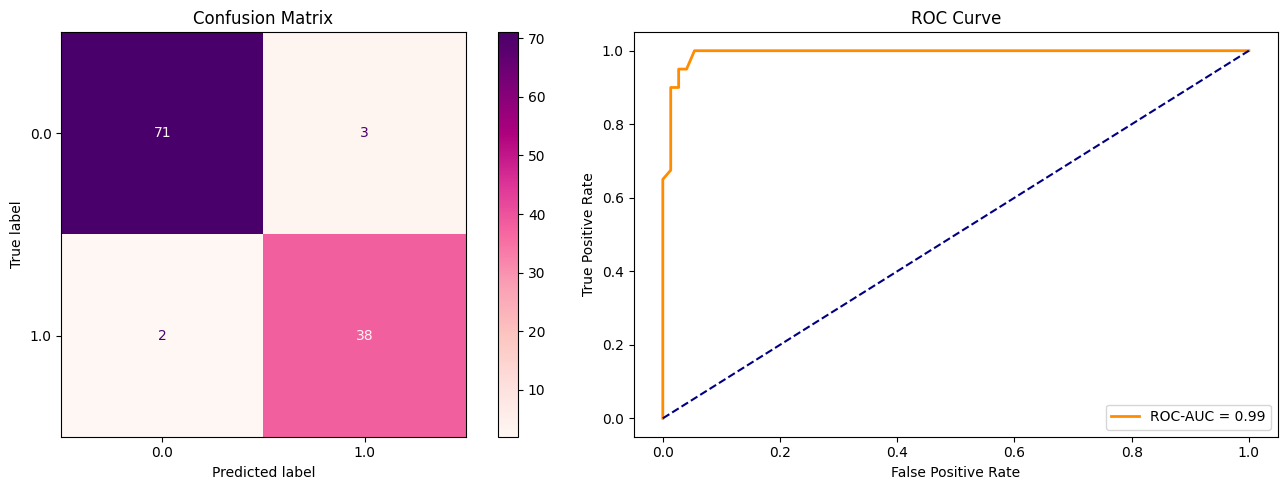

PR-AUC (Precision-Recall AUC): 0.9859


In [47]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='RdPu')
ax[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.2f}', color='darkorange', lw=2)
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"PR-AUC (Precision-Recall AUC): {pr_auc:.4f}")

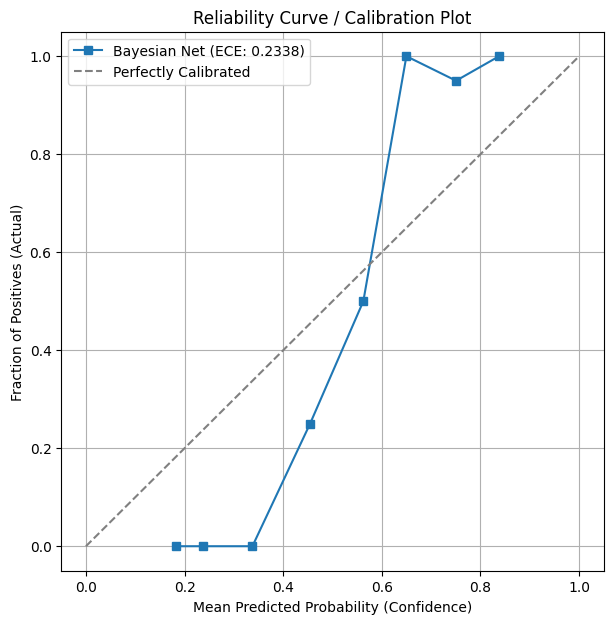

In [48]:
def calculate_ece(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0
    for j in range(n_bins):
        mask = binids == j
        if np.any(mask):
            weight = np.mean(mask)
            diff = np.abs(np.mean(y_true[mask]) - np.mean(y_prob[mask]))
            ece += weight * diff
    return ece

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
ece_val = calculate_ece(y_test, y_prob)

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker='s', ls='-', label=f'Bayesian Net (ECE: {ece_val:.4f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability (Confidence)')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Reliability Curve / Calibration Plot')
plt.legend()
plt.grid(True)
plt.show()

**CART MODELING**

In [52]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
cart_model = DecisionTreeClassifier(criterion='gini')

In [54]:
cart_model = cart_model.fit(X=X_train, y=y_train)

In [60]:
y_pred_cart = cart_model.predict(X_test)

y_prob_cart = cart_model.predict_proba(X_test)[:, 1]

CART Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95        74
         1.0       0.90      0.93      0.91        40

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



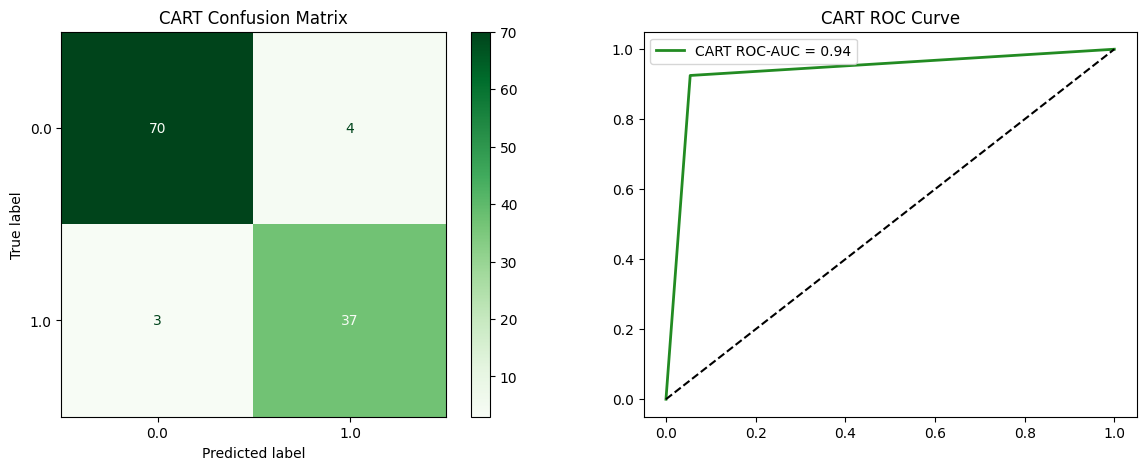

CART PR-AUC: 0.9269


In [ ]:
# Classification Report 
print("CART Model Classification Report:")
print(classification_report(y_test, y_pred_cart))

# Confusion Matrix and ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cart, ax=ax[0], cmap='Greens')
ax[0].set_title("CART Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_cart)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f'CART ROC-AUC = {roc_auc:.2f}', color='forestgreen', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title("CART ROC Curve")
ax[1].legend()

plt.show()

# PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob_cart)
print(f"CART PR-AUC: {auc(recall, precision):.4f}")

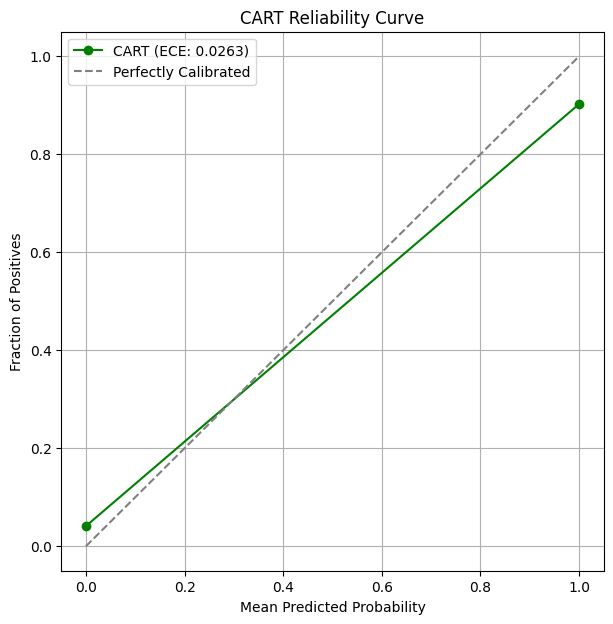

In [ ]:
# Reliability Curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_cart, n_bins=10)
ece_cart = calculate_ece(y_test, y_prob_cart) 

plt.figure(figsize=(7, 7))
plt.plot(prob_pred, prob_true, marker='o', ls='-', label=f'CART (ECE: {ece_cart:.4f})', color='green')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('CART Reliability Curve')
plt.legend()
plt.grid(True)
plt.show()

**CATEGORICAL-NB MODELING**

In [56]:
from sklearn.naive_bayes import CategoricalNB

In [57]:
categorical_nb_model = CategoricalNB(alpha=1)

In [58]:
categorical_nb_model = categorical_nb_model.fit(X=X_train, y=y_train)

In [64]:
y_pred_nb = categorical_nb_model.predict(X_test)

y_prob_nb = categorical_nb_model.predict_proba(X_test)[:, 1]

In [65]:
print("Categorical Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

Categorical Naive Bayes Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.96      0.95        74
         1.0       0.92      0.90      0.91        40

    accuracy                           0.94       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



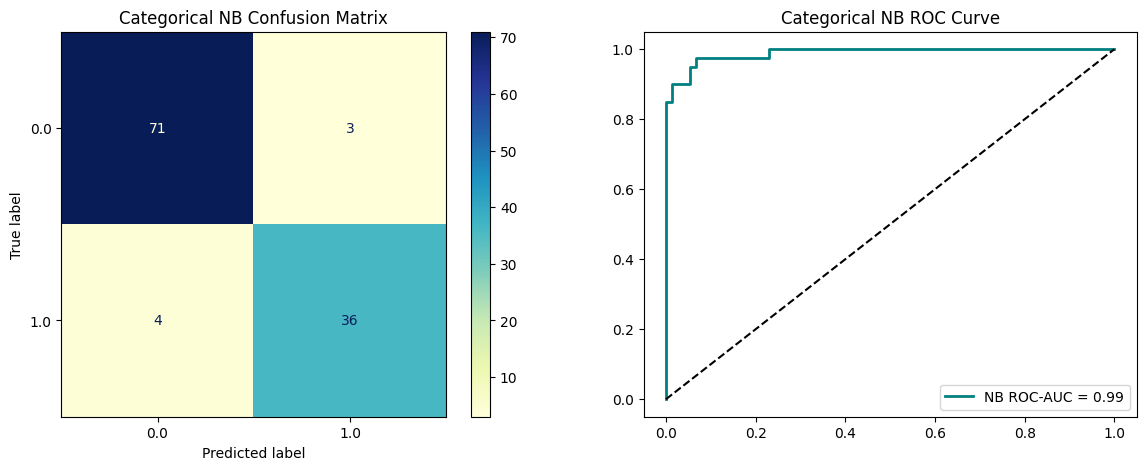

In [67]:
# Visualization: Confusion Matrix and ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, ax=ax[0], cmap='YlGnBu')
ax[0].set_title("Categorical NB Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, label=f'NB ROC-AUC = {roc_auc:.2f}', color='teal', lw=2)
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title("Categorical NB ROC Curve")
ax[1].legend()
plt.show()

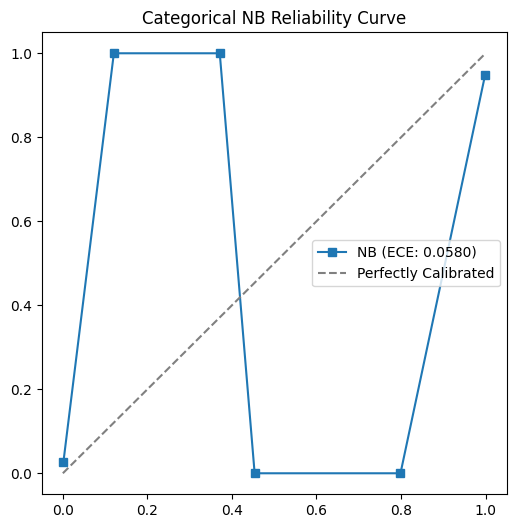

In [68]:
# Reliability Curve and ECE
prob_true_nb, prob_pred_nb = calibration_curve(y_test, y_prob_nb, n_bins=10)
ece_nb = calculate_ece(y_test, y_prob_nb) # Using the function defined previously

plt.figure(figsize=(6, 6))
plt.plot(prob_pred_nb, prob_true_nb, marker='s', label=f'NB (ECE: {ece_nb:.4f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly Calibrated')
plt.title('Categorical NB Reliability Curve')
plt.legend()
plt.show()

**SVM MODELING**

In [77]:
from sklearn.svm import SVC

In [78]:
svm_linear_model = SVC(kernel='linear', probability=True, random_state=42)
svm_rbf_model = SVC(kernel='rbf', probability=True, random_state=42)

In [79]:
svm_linear_model = svm_linear_model.fit(X=X_train, y=y_train)
svm_rbf_model = svm_rbf_model.fit(X=X_train, y=y_train)


Evaluating SVM Linear...
SVM Linear Report:
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.97        74
         1.0       0.93      0.97      0.95        40

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



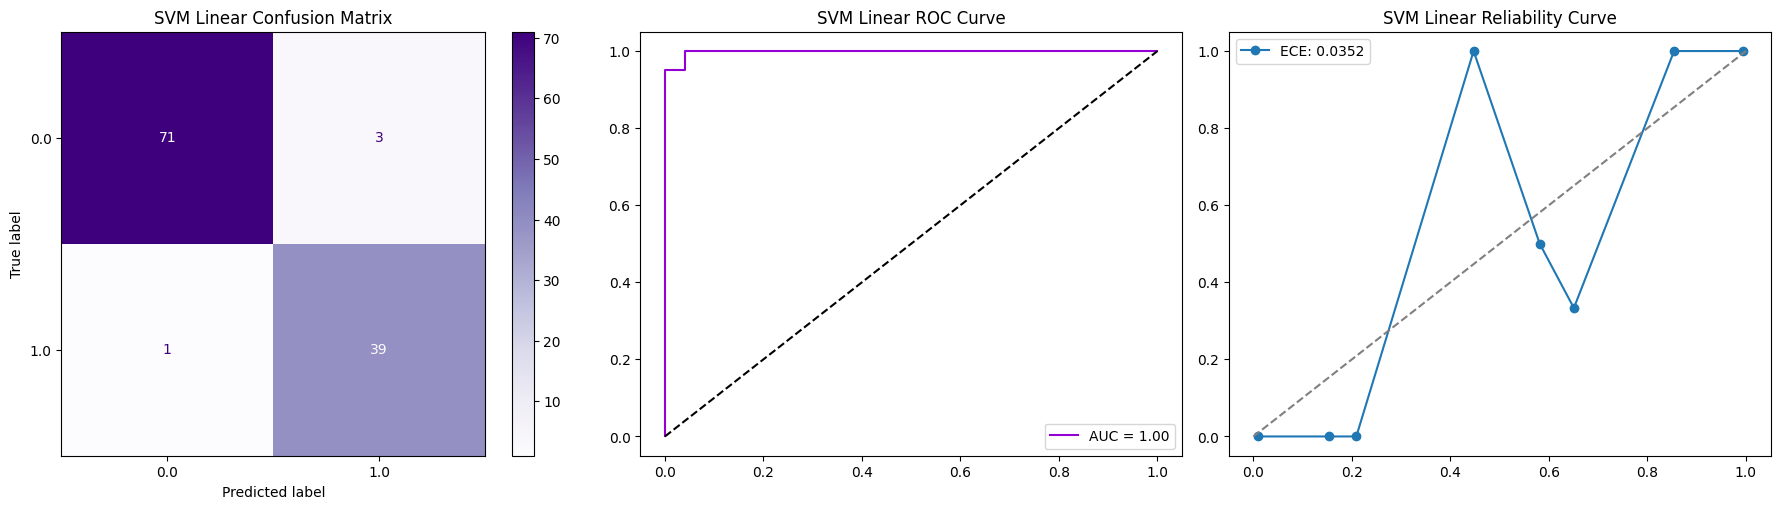


Evaluating SVM RBF...
SVM RBF Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99        74
         1.0       0.98      1.00      0.99        40

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



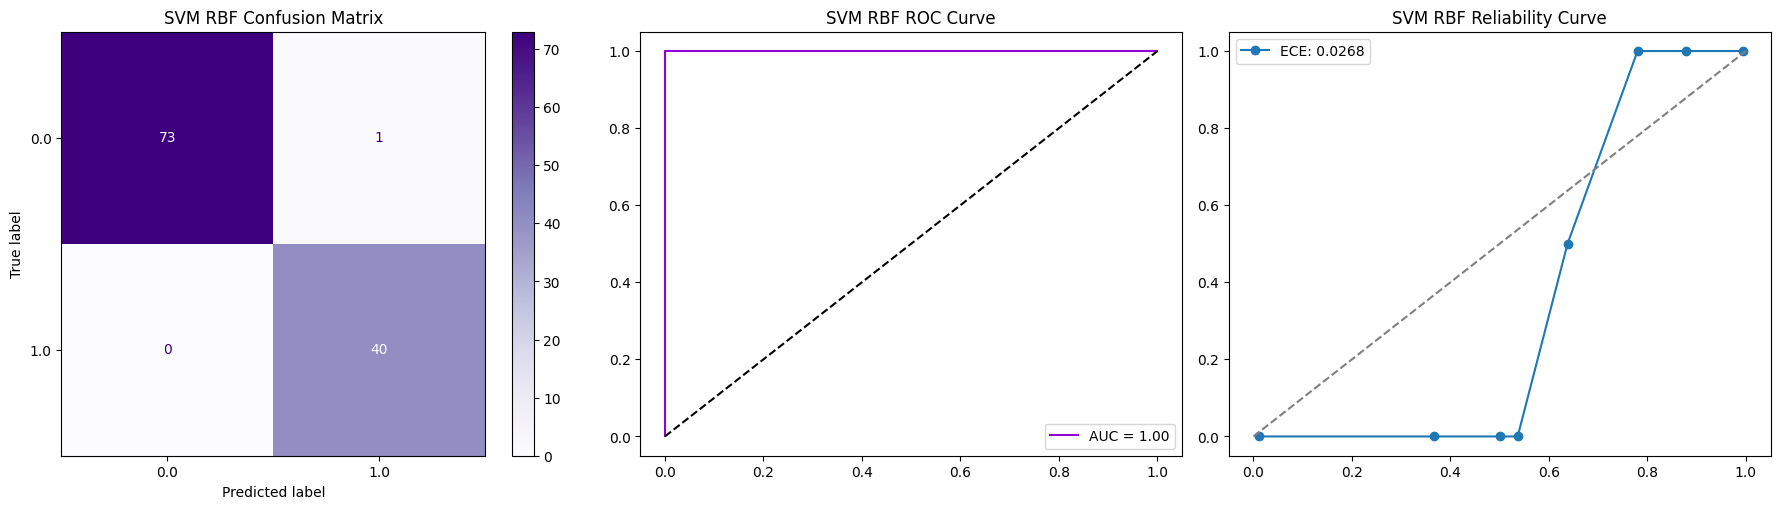

In [80]:
# Store in a list for iteration
svm_list = [
    ("SVM Linear", svm_linear_model),
    ("SVM RBF", svm_rbf_model)
]

# Evaluation Loop 
X_test_svm = df_test_discrete[cols_without_target_and_id]

for name, model in svm_list:
    print(f"\nEvaluating {name}...")
    
    # Generate predictions
    y_pred = model.predict(X_test_svm)
    y_prob = model.predict_proba(X_test_svm)[:, 1]
    
    # Classification Report
    print(f"{name} Report:")
    print(classification_report(y_test, y_pred))
    
    # Visualization
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Purples')
    ax[0].set_title(f"{name} Confusion Matrix")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='darkviolet')
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_title(f"{name} ROC Curve")
    ax[1].legend()
    
    # Reliability Curve (using the calculate_ece function from before)
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    ece_val = calculate_ece(y_test, y_prob)
    ax[2].plot(prob_pred, prob_true, marker='o', label=f'ECE: {ece_val:.4f}')
    ax[2].plot([0, 1], [0, 1], '--', color='gray')
    ax[2].set_title(f"{name} Reliability Curve")
    ax[2].legend()
    
    plt.tight_layout()
    plt.show()